In [3]:
# ===== 1. Import =====
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction import FeatureHasher

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

df = pd.read_csv("musicData.csv")

df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [5]:
# ===== 3. Basic Cleaning =====

# Drop rows with missing values (simple & safe for presentation)
df = df.dropna()

# Convert tempo to numeric (some are strings)
df["tempo"] = pd.to_numeric(df["tempo"], errors="coerce")

df = df.dropna()

In [ ]:
# ===== 4. Encode Categorical Variables =====

# Key mapping
key_mapping = {'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4,
               'F': 5, 'F#': 6, 'G': 7, 'G#': 8,
               'A': 9, 'A#': 10, 'B': 11}

df["key"] = df["key"].map(key_mapping)
df = pd.get_dummies(df, columns=["mode"], drop_first=True)
df["music_genre"] = df["music_genre"].astype("category").cat.codes

In [9]:
# ===== 5. Feature Hashing (text features) =====

hasher = FeatureHasher(n_features=10, input_type="string")

artist_input = df["artist_name"].astype(str).apply(lambda x: [x])
artist_hashed = hasher.transform(artist_input)
artist_df = pd.DataFrame(
    artist_hashed.toarray(),
    columns=[f"artist_hash_{i}" for i in range(10)]
)

track_input = df["track_name"].astype(str).apply(lambda x: [x])
track_hashed = hasher.transform(track_input)
track_df = pd.DataFrame(
    track_hashed.toarray(),
    columns=[f"track_hash_{i}" for i in range(10)]
)

df = pd.concat(
    [df.reset_index(drop=True), artist_df, track_df],
    axis=1
)

df = df.drop(columns=["artist_name", "track_name"])

In [10]:
# ===== 6. Select Features =====

# Drop non-useful columns
X = df.drop(columns=["music_genre", "instance_id", "obtained_date"], errors="ignore")
y = df["music_genre"]

In [11]:
# ===== 7. Standardization =====

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# ===== 8. PCA =====

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

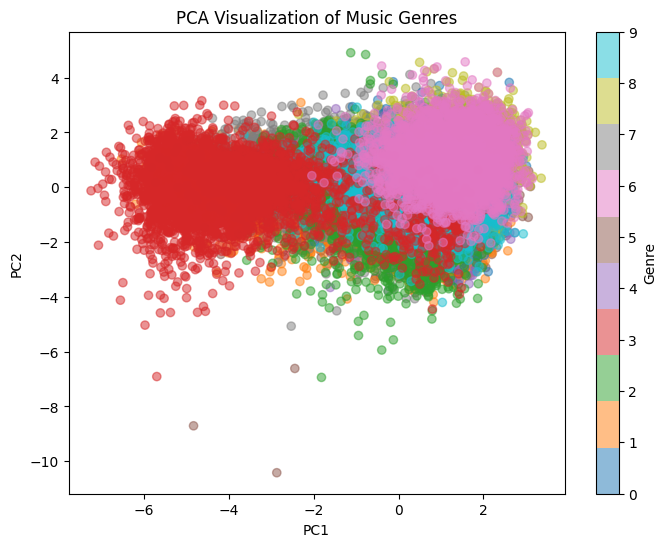

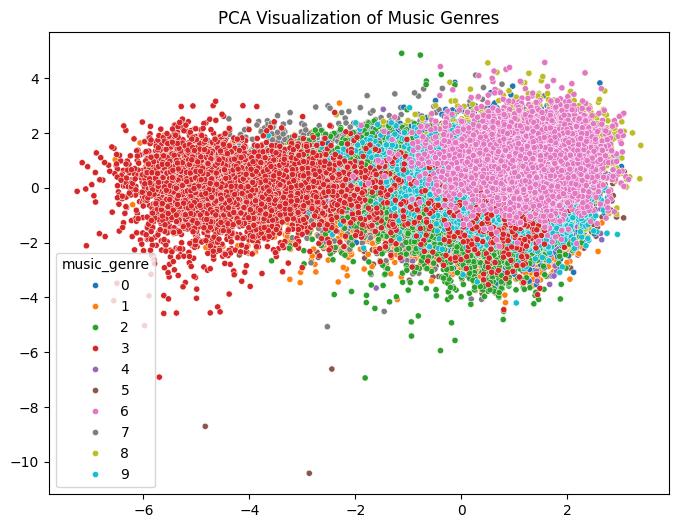

In [ ]:
# ===== 9. Visualization =====
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="tab10", s=20)
plt.title("PCA Visualization of Music Genres")
plt.show()

In [17]:
df.to_csv("processed_musicData.csv", index=False)